### 1. 필요한 라이브러리 호출

In [15]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### 얕은 복사와 깊은 복사


##### 1. 단순 객체 복사

In [16]:
original = [1,2,3]
copy_o = original
print(copy_o)

copy_o[2] = 10
print(copy_o)
print(original)

[1, 2, 3]
[1, 2, 10]
[1, 2, 10]


- copy_o 뿐만 아니라 원래 값인 originaldml 3도 10으로 바뀜

##### 2. 얕은 복사

In [17]:
import copy
original = [[1,2],3]
copy_o = copy.copy(original)
print(copy_o)
copy_o[0]=100
print(copy_o)
print(original)

append = copy.copy(original)
append[0].append(4)
print(append)
print(original)

[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2, 4], 3]


- copy_o에서 [1,2]값을 100으로 변경했더니, copy_o만 바뀜
- [1,2]에 4를 추가헸더니 original과 copy_o 모두 반영됨

##### 3. 깊은 복사

In [18]:
import copy
original = [[1,2],3]
copy_o = copy.deepcopy(original)
print(copy_o)
copy_o[0]=100
print(copy_o)
print(original)

append = copy.deepcopy(original)
append[0].append(4)
print(append)
print(original)

[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2], 3]


- copy_o 에서 [1, 2]값을 100 으로 변경했더니 copy_o만 바뀐 것은 동일
- 또한 , [1, 2]에 4를 추가했더니 copy_0는 변경되었지만, original은 그대로

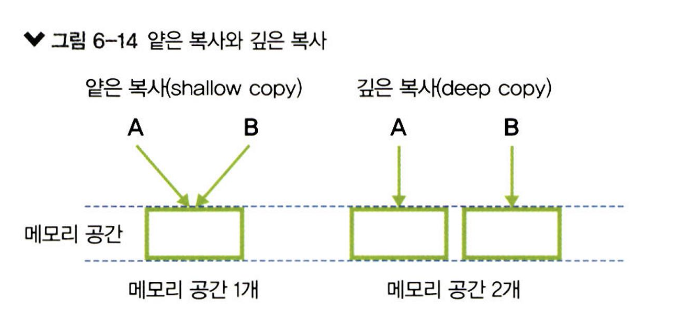

### 2. VGG 모델 정의

In [19]:
class VGG(nn.Module):
    def __init__(self, features, output_dim):
        super().__init__()
        self.features = features # VGG 모델에 대한 매개변수에서 받아 온 features 값을 self.features에 넣어줌
        self.avgpool = nn.AdaptiveAvgPool2d(7)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            nn.Linear(4096, output_dim),
        ) # 완전연결층과 출력층 정의

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        h = x.view(x.shape[0], -1)
        x = self.classifier(h)
        return x, h

### 3. 모델 유형 정의

In [20]:
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
# 8(합성곱층) + 3(풀링층) = 11(전체계층) = VGG11

vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
# 10(합성곱층) + 3(폴링층) = 13(전체 계층) = VGG13

vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512,
                512, 'M']
# 13(합성곱층) + 3(폴링층) = 16(전체 계층) = VGG16

vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M',
                512, 512, 512, 512, 'M']
# 16(합성곱층) + 3(폴링층) = 19(전체 계층) = VGG19

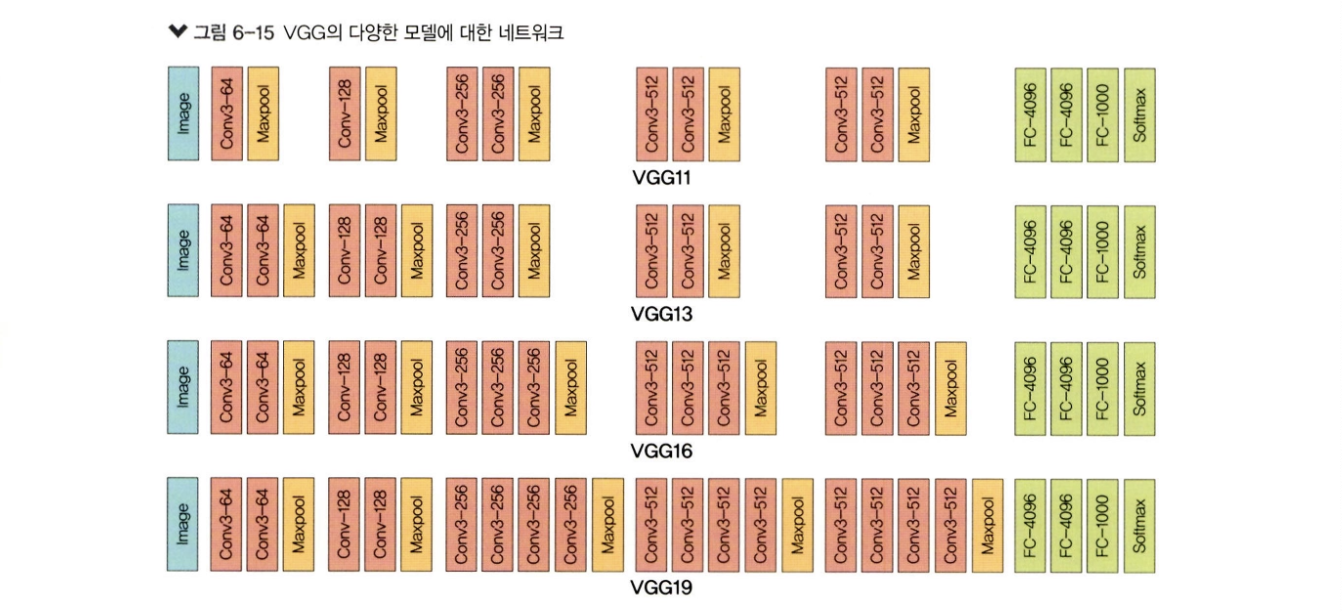

### 4. VGG 계층 정의

In [21]:
def get_vgg_layers(config, batch_norm):
    layers = []
    in_channels = 3

    for c in config:
        assert c == 'M' or isinstance(c, int)
        if c == 'M':
            layers += [nn.MaxPool2d(kernel_size = 2)]
        else:
            conv2d = nn.Conv2d(in_channels, c, kernel_size = 3, padding = 1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace = True)]
            else:
                layers += [conv2d, nn.ReLU(inplace = True)]
            in_channels = c

    return nn.Sequential(*layers)

### 5. 모델 계층 생성

In [22]:
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm = True)

### 6. VGG11 계층 확인

In [23]:
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

### 7. VGG11 전체에 대한 네트워크

In [24]:
OUTPUT_DIM = 2
model = VGG(vgg11_layers, OUTPUT_DIM).to(device)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

### 8. VGG11 사전 훈련된 모델 사용

In [25]:
import torchvision.models as models

pretrained_model = models.vgg11_bn(pretrained = True)
print(pretrained_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

### 9. 이미지 데이터 전처리

In [26]:
train_transforms = transforms.Compose([
                           transforms.Resize((256, 256)),
                           transforms.RandomRotation(5),
                           transforms.RandomHorizontalFlip(0.5),
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

test_transforms = transforms.Compose([
                           transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

### 10. ImageFolder를 이용하여 데이터셋 불러오기

In [27]:
from google.colab import files
file_uploaded=files.upload()

Saving catanddog.zip to catanddog.zip


In [28]:
!unzip catanddog.zip
!unzip catanddog.zip -d catanddog/

Archive:  catanddog.zip
   creating: test/
   creating: test/Cat/
  inflating: test/Cat/8104.jpg       
  inflating: test/Cat/8105.jpg       
  inflating: test/Cat/8106.jpg       
  inflating: test/Cat/cat.12426.jpg  
  inflating: test/Cat/cat.12495.jpg  
  inflating: test/Cat/cat.12496.jpg  
   creating: test/Dog/
  inflating: test/Dog/dog.116.jpg    
  inflating: test/Dog/dog.212.jpg    
  inflating: test/Dog/dog.213.jpg    
  inflating: test/Dog/dog.214.jpg    
  inflating: test/Dog/dog.215.jpg    
  inflating: test/Dog/dog.224.jpg    
   creating: train/
   creating: train/Cat/
  inflating: train/Cat/0.jpg         
  inflating: train/Cat/1.jpg         
  inflating: train/Cat/10.jpg        
  inflating: train/Cat/11.jpg        
  inflating: train/Cat/12.jpg        
  inflating: train/Cat/13.jpg        
  inflating: train/Cat/14.jpg        
  inflating: train/Cat/15.jpg        
  inflating: train/Cat/16.jpg        
  inflating: train/Cat/17.jpg        
  inflating: train/Cat/18.jpg  

In [29]:
train_path = '/content/catanddog/train'
test_path = '/content/catanddog/test'

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)

test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

529
12


(None, None)

### 11. 훈련과 검증 데이터 분할

In [30]:
VALID_RATIO = 0.9
n_train_examples = int(len(train_dataset) * VALID_RATIO)
n_valid_examples = len(train_dataset) - n_train_examples

train_data, valid_data = data.random_split(train_dataset,
                                           [n_train_examples, n_valid_examples])

### 12. 검증 데이터 전처리

In [31]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

### 13. 훈련, 검증, 테스트 데이터셋 수 확인

In [32]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 476
Number of validation examples: 53
Number of testing examples: 12


### 14. 메모리로 데이터 불러오기

In [33]:
BATCH_SIZE = 32
train_iterator = data.DataLoader(train_data,
                                 shuffle = True,
                                 batch_size = BATCH_SIZE)

valid_iterator = data.DataLoader(valid_data,
                                 batch_size = BATCH_SIZE)

test_iterator = data.DataLoader(test_dataset,
                                batch_size = BATCH_SIZE)

### 15. 옵티마이저의 손실 함수 정의

In [34]:
optimizer = optim.Adam(model.parameters(), lr = 1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

### 16. 모델 정확도 측정 함수

In [35]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim = True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

### 17. 모델 학습 함수 정의

In [36]:
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.train()
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

### 18. 모델 성능 측정 함수

In [37]:
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()
    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            y_pred, _ = model(x)
            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

### 19. 학습 시간 측정 함수

In [38]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

### 20. 모델 학습

In [39]:
import time

EPOCHS = 5
best_valid_loss = float('inf')
for epoch in range(EPOCHS):
    start_time = time.monotonic()
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'VGG-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Valid. Loss: {valid_loss:.3f} |  Valid. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 0m 16s
	Train Loss: 0.704 | Train Acc: 49.08%
	 Valid. Loss: 0.693 |  Valid. Acc: 56.70%
Epoch: 02 | Epoch Time: 0m 9s
	Train Loss: 0.699 | Train Acc: 47.77%
	 Valid. Loss: 0.693 |  Valid. Acc: 52.75%
Epoch: 03 | Epoch Time: 0m 7s
	Train Loss: 0.703 | Train Acc: 48.04%
	 Valid. Loss: 0.697 |  Valid. Acc: 45.68%
Epoch: 04 | Epoch Time: 0m 7s
	Train Loss: 0.703 | Train Acc: 46.37%
	 Valid. Loss: 0.696 |  Valid. Acc: 47.17%
Epoch: 05 | Epoch Time: 0m 7s
	Train Loss: 0.684 | Train Acc: 56.16%
	 Valid. Loss: 0.696 |  Valid. Acc: 44.87%


### 21. 테스트 데이터셋을 이용한 모델 성능 측정

In [40]:
model.load_state_dict(torch.load('VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.693 | Test Acc: 50.00%


### 22. 테스트 데이터셋을 이용한 모델의 예측 확인 함수

In [41]:
def get_predictions(model, iterator):
    model.eval()
    images = []
    labels = []
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y_pred, _ = model(x)
            y_prob = F.softmax(y_pred, dim = -1)
            top_pred = y_prob.argmax(1, keepdim = True)
            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim = 0)
    labels = torch.cat(labels, dim = 0)
    probs = torch.cat(probs, dim = 0)
    return images, labels, probs

- **torch.cat**
  - 텐서를 연결할 때 사용합니다. 다음 예제를 통해 사용 방법을 확인 가능
    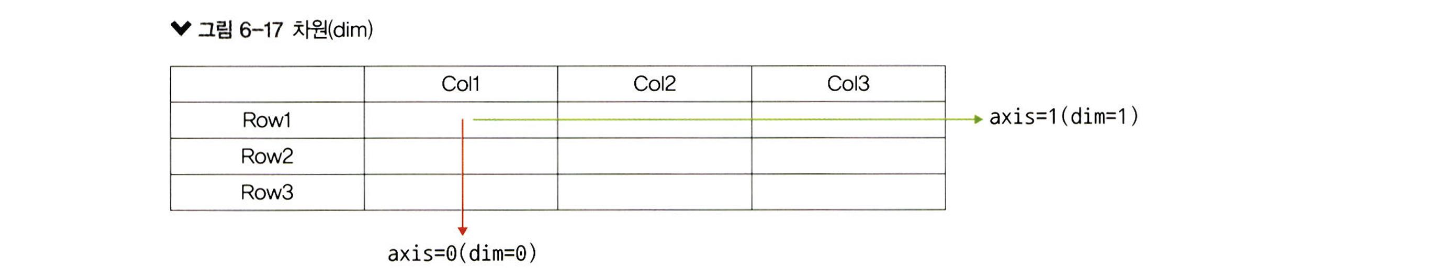

In [42]:
import torch
x = torch.Tensor([[1,2,3],[2,3,4]])
y = torch.Tensor([[4,5,6],[5,6,7]])

print(torch.cat([x],dim=0))
print(torch.cat([x,y]))
print(torch.cat([x,y],dim=0))
print(torch.cat([x,y],dim=1))

tensor([[1., 2., 3.],
        [2., 3., 4.]])
tensor([[1., 2., 3.],
        [2., 3., 4.],
        [4., 5., 6.],
        [5., 6., 7.]])
tensor([[1., 2., 3.],
        [2., 3., 4.],
        [4., 5., 6.],
        [5., 6., 7.]])
tensor([[1., 2., 3., 4., 5., 6.],
        [2., 3., 4., 5., 6., 7.]])


### 23. 예측 중에서 정확하게 예측한 것을 추출

In [43]:
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)
corrects = torch.eq(labels, pred_labels)
correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if correct:
        correct_examples.append((image, label, prob))

correct_examples.sort(reverse = True, key = lambda x: torch.max(x[2], dim = 0).values)

- **zip()** : 여러 개의 리스트(튜플)을 합쳐서 새로운 튜플 타입으로 반환
  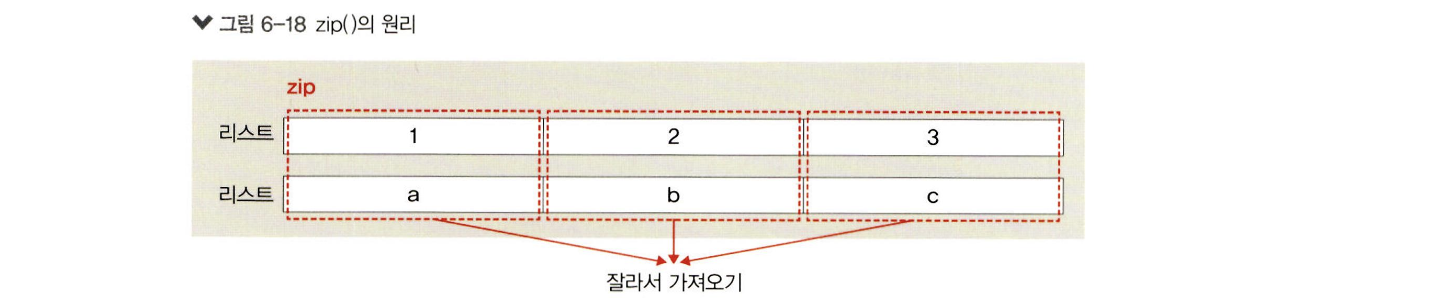

In [44]:
a = [1,2,3]
b = ['a','b','c']

for x, y in zip(a,b):
  print(x,y)

1 a
2 b
3 c


### 24. 이미지 출력을 위한 전처리

In [45]:
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

### 25. 모델이 정확하게 예측한 이미지 출력 함수

In [46]:
def plot_most_correct(correct, classes, n_images, normalize = True):
    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))
    fig = plt.figure(figsize = (25, 20))
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1) # 출력하려는 그래프 개수만큼 subplot을 만듦
        image, true_label, probs = correct[i]
        image = image.permute(1, 2, 0)
        true_prob = probs[true_label]
        correct_prob, correct_label = torch.max(probs, dim = 0)
        true_class = classes[true_label]
        correct_class = classes[correct_label]

        if normalize: # 본래 이미지대로 출력하기 위해 normalize_image 함수 출력
            image = normalize_image(image)

        ax.imshow(image.cpu().numpy())
        ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n' \
                     f'pred label: {correct_class} ({correct_prob:.3f})')
        ax.axis('off')

    fig.subplots_adjust(hspace = 0.4)

### 26. 예측 결과 이미지 출력

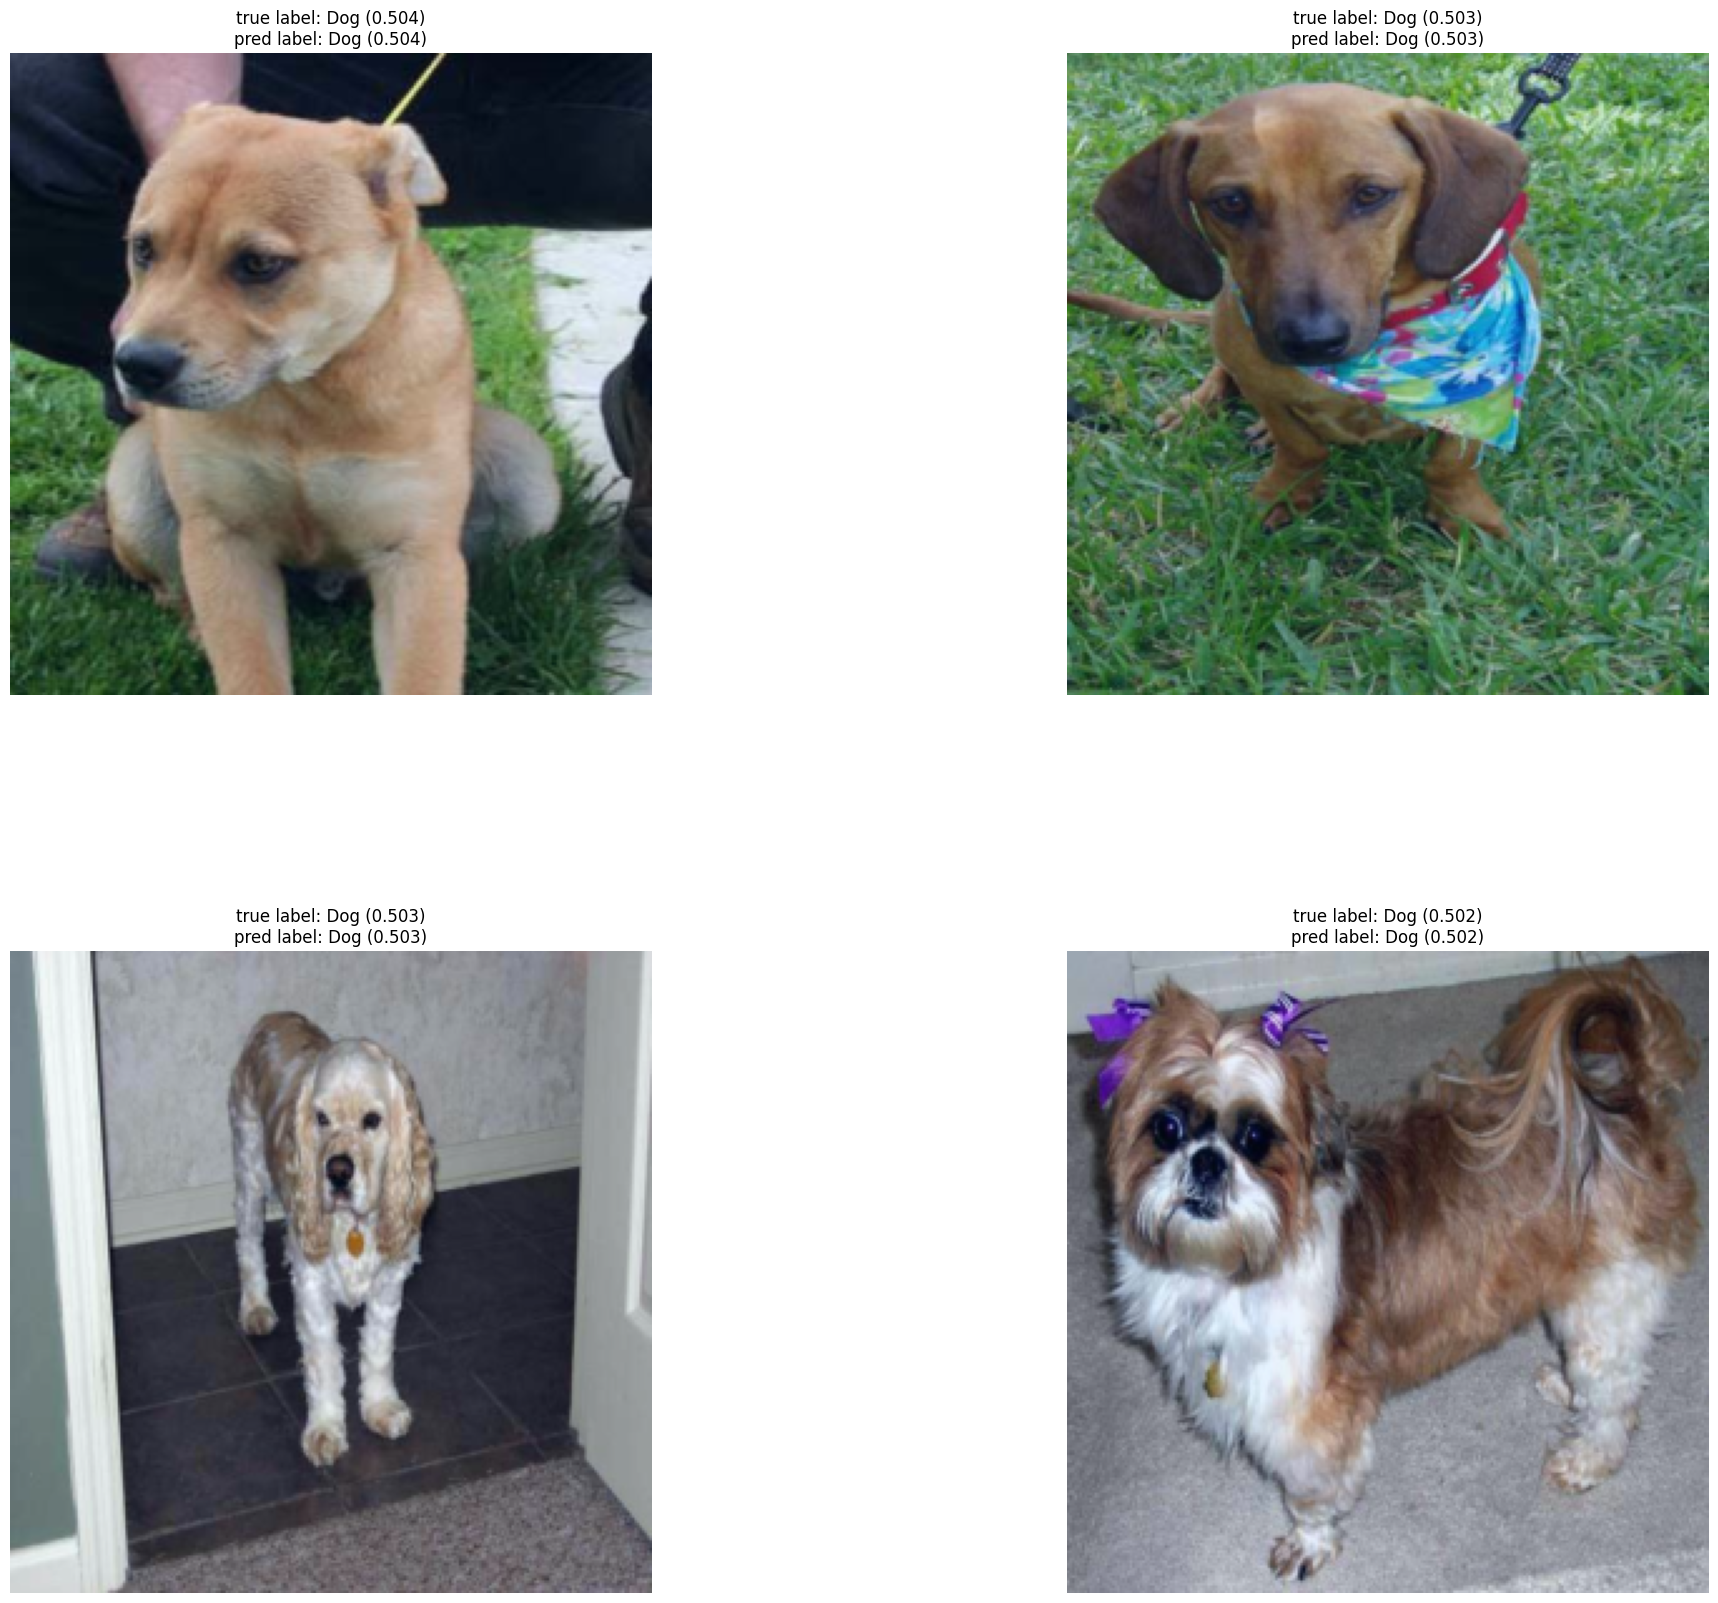

In [47]:
classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)